In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
titanic_test = pd.read_csv("C:/Users/Home/Desktop/Projects/Titanic Survivals Analysis/data/test.csv")
titanic_train = pd.read_csv("C:/Users/Home/Desktop/Projects/Titanic Survivals Analysis/data/train.csv")
titanic_gen_sub = pd.read_csv("C:/Users/Home/Desktop/Projects/Titanic Survivals Analysis/data/gender_submission.csv")

## <b> <center> EXPLORATORY DATA ANALYSIS </center> </b>

In [3]:
titanic_train.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
64,65,0,1,"Stewart, Mr. Albert A",male,NaN,0,0,PC 17605,27.7208,NaN,C
349,350,0,3,"Dimic, Mr. Jovan",male,42.0,0,0,315088,8.6625,NaN,S
160,161,0,3,"Cribb, Mr. John Hatfield",male,44.0,0,1,371362,16.1000,NaN,S
830,831,1,3,"Yasbeck, Mrs. Antoni (Selini Alexander)",female,15.0,1,0,2659,14.4542,NaN,C
265,266,0,2,"Reeves, Mr. David",male,36.0,0,0,C.A. 17248,10.5000,NaN,S
80,81,0,3,"Waelens, Mr. Achille",male,22.0,0,0,345767,9.0000,NaN,S
251,252,0,3,"Strom, Mrs. Wilhelm (Elna Matilda Persson)",female,29.0,1,1,347054,10.4625,G6,S
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
677,678,1,3,"Turja, Miss. Anna Sofia",female,18.0,0,0,4138,9.8417,NaN,S


In [4]:
titanic_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
titanic_train.shape

(891, 12)

In [6]:
titanic_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
titanic_train.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
titanic_train.describe(include = 'all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [9]:
titanic_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
titanic_train.duplicated().sum()

np.int64(0)

In [11]:
titanic_train.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


## <b><center>Exploratory Data Analysis</b>

In [12]:
titanic_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [13]:
df = titanic_train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

In [14]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [15]:
df.shape

(891, 8)

In [16]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_39228\1419413682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Survived'], color='skyblue', palette=['lightblue', 'salmon'])


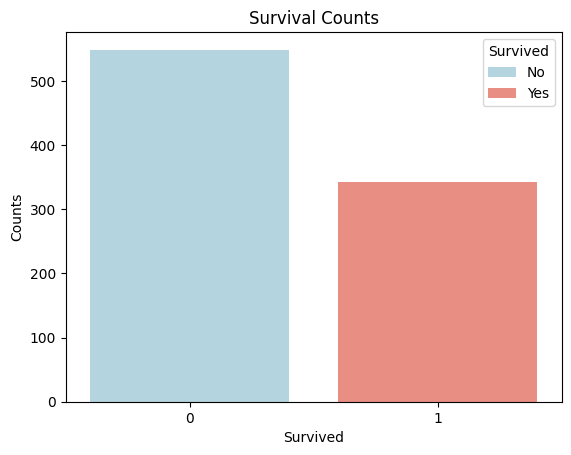

In [17]:
plt.figsize = (12, 5)

sns.countplot(x = df['Survived'], color='skyblue', palette=['lightblue', 'salmon'])
plt.title('Survival Counts')
plt.xlabel("Survived")
plt.ylabel("Counts")

plt.legend(title = 'Survived', labels = ['No', 'Yes'])

plt.show()

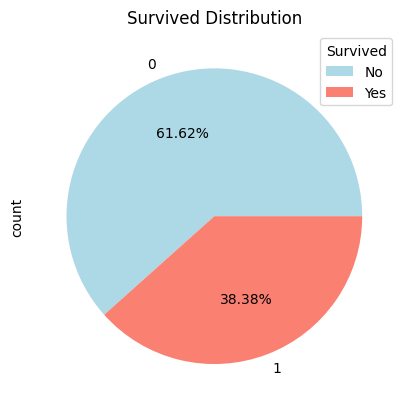

In [18]:
plt.figsize = (12, 5)

df['Survived'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon'])

plt.title("Survived Distribution")
plt.legend(title = 'Survived', labels = ['No', 'Yes'])

plt.show()

In [49]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_39228\122211628.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Pclass'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])


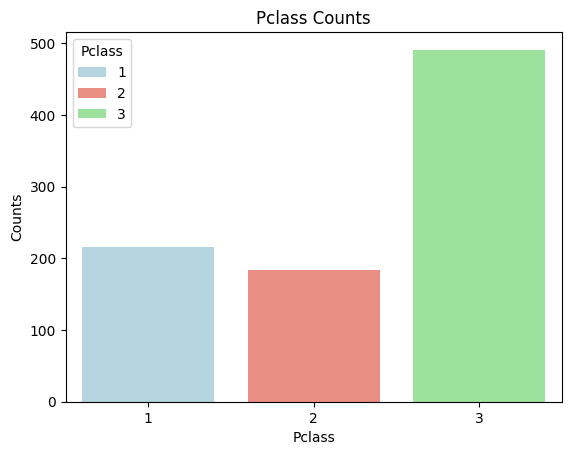

In [22]:
plt.figsize = (12, 5)

sns.countplot(x = df['Pclass'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])
plt.title('Pclass Counts')
plt.xlabel("Pclass")
plt.ylabel("Counts")

plt.legend(title = 'Pclass', labels = ['1', '2', '3'])

plt.show()

In [23]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

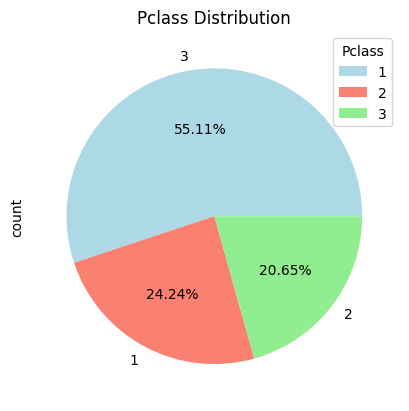

In [30]:
plt.figsize = (12, 5)

df['Pclass'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen'])

plt.title("Pclass Distribution")
plt.legend(title = 'Pclass', labels = ['1', '2', '3'])

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_39228\2357880717.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Sex'], color='skyblue', palette=['lightblue', 'salmon'])


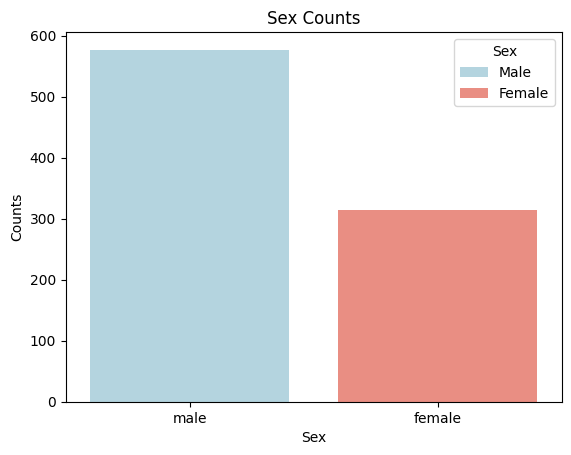

In [31]:
plt.figsize = (12, 5)

sns.countplot(x = df['Sex'], color='skyblue', palette=['lightblue', 'salmon'])
plt.title('Sex Counts')
plt.xlabel("Sex")
plt.ylabel("Counts")

plt.legend(title = 'Sex', labels = ['Male', 'Female'])

plt.show()

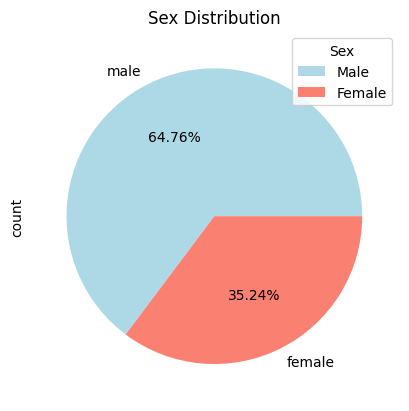

In [32]:
plt.figsize = (12, 5)

df['Sex'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon'])

plt.title("Sex Distribution")
plt.legend(title = 'Sex', labels = ['Male', 'Female'])

plt.show()

In [42]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_39228\3655727618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['SibSp'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightcyan', 'lightseagreen'])
C:\Users\Home\AppData\Local\Temp\ipykernel_39228\3655727618.py:3: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.countplot(x = df['SibSp'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightcyan', 'lightseagreen'])


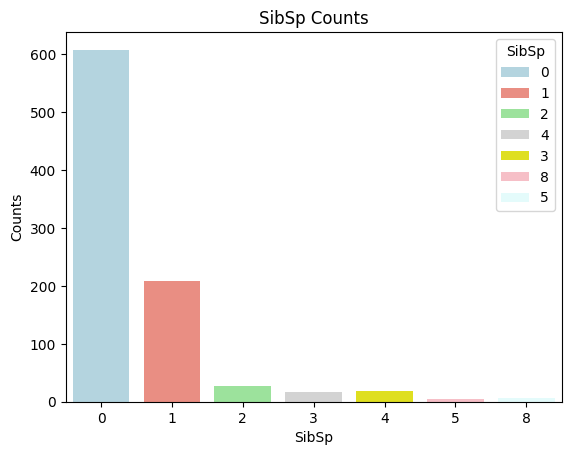

In [43]:
plt.figsize = (12, 5)

sns.countplot(x = df['SibSp'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightcyan', 'lightseagreen'])
plt.title('SibSp Counts')
plt.xlabel("SibSp")
plt.ylabel("Counts")

plt.legend(title = 'SibSp', labels = ['0', '1', '2', '4', '3', '8', '5'])

plt.show()

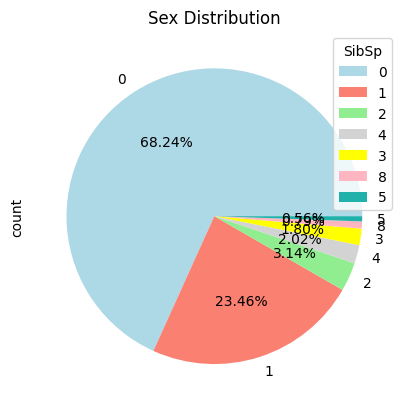

In [47]:
plt.figsize = (12, 5)

df['SibSp'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])

plt.title("Sex Distribution")
plt.legend(title = 'SibSp', labels = ['0', '1', '2', '4', '3', '8', '5'])

plt.show()

In [45]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_39228\2915405946.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Parch'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])


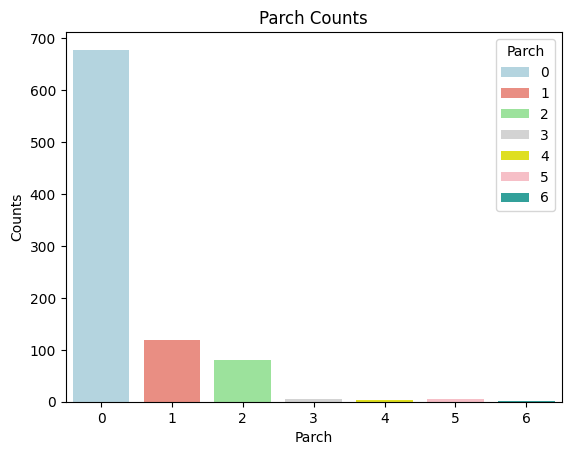

In [48]:
plt.figsize = (12, 5)

sns.countplot(x = df['Parch'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])
plt.title('Parch Counts')
plt.xlabel("Parch")
plt.ylabel("Counts")

plt.legend(title = 'Parch', labels = ['0', '1', '2', '3', '4', '5', '6'])

plt.show()

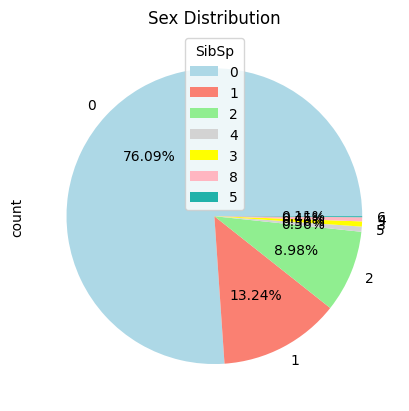

In [52]:
plt.figsize = (12, 5)

df['Parch'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])

plt.title("Sex Distribution")
plt.legend(title = 'SibSp', labels = ['0', '1', '2', '4', '3', '8', '5'])

plt.show()

In [53]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_39228\3126860859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Embarked'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])


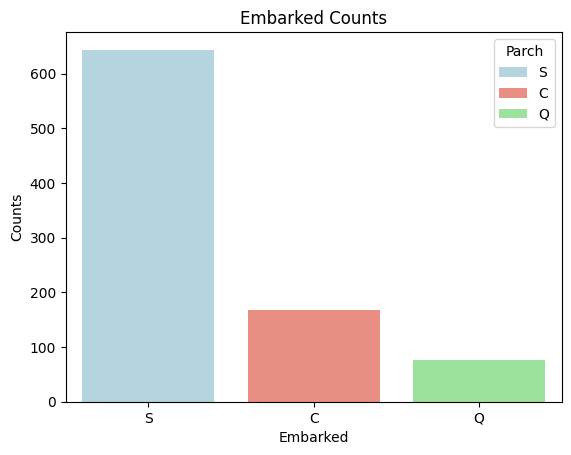

In [54]:
plt.figsize = (12, 5)

sns.countplot(x = df['Embarked'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])
plt.title('Embarked Counts')
plt.xlabel("Embarked")
plt.ylabel("Counts")

plt.legend(title = 'Parch', labels = ['S', 'C', 'Q'])

plt.show()

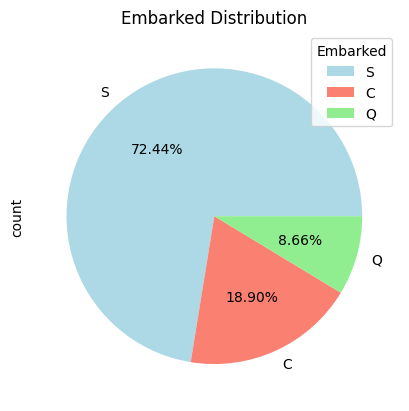

In [56]:
plt.figsize = (12, 5)

df['Embarked'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])

plt.title("Embarked Distribution")
plt.legend(title = 'Embarked', labels = ['S', 'C', 'Q'])

plt.show()